In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import r2_score
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
# Assumes: import pandas as pd, numpy as np, statsmodels.api as sm

def variable_pd_analysis(
    df,
    var_names,
    target='default_12m',
    date_col='stmt_date',
    combined=False,
    cluster_by=None,     # e.g., 'id' to cluster SEs by firm
    drop_na='pairwise',  # 'pairwise' (per var) | 'listwise' (same rows for all vars)
    combined_only=False
):
    """
    Diagnostic PD logit: univariate pooled effects (no year controls), yearly stability by grouping,
    and optional combined model (also without year dummies). Prints summaries; returns a dict of results.

    Notes:
      - NO year fixed effects are included anywhere.
      - __year__ is computed only for the 'yearly stability' reporting (grouping), not as a regressor.
    """

    # ---- normalize inputs ----
    var_list = [var_names] if isinstance(var_names, str) else list(var_names)
    if drop_na not in ('pairwise', 'listwise'):
        raise ValueError("drop_na must be 'pairwise' or 'listwise'")

    df = df.copy()
    # Kept only for grouping in yearly stability (not used in regressions)
    df['__year__'] = pd.to_datetime(df[date_col], errors='coerce').dt.year

    # ---- helpers ----
    def _fit_logit(endog, exog, groups=None, disp=0):
        model = sm.Logit(endog, exog)
        if groups is not None:
            return model.fit(disp=disp, cov_type='cluster', cov_kwds={'groups': groups})
        else:
            return model.fit(disp=disp, cov_type='HC1')

    def _is_binary_series(s: pd.Series) -> bool:
        u = s.dropna().unique()
        if len(u) == 0:
            return False
        return set(np.unique(u)).issubset({0, 1})

    def _margeff_univariate(result, data, var_name):
        # treat dummies as discrete 0->1; continuous as derivative
        is_bin = _is_binary_series(data[var_name])
        return result.get_margeff(at='overall', method='dydx', dummy=is_bin)

    def _margeff_combined(result, d_all, var_list):
        """
        Align dummy flags to exog order (excluding const). Only original predictors appear.
        """
        exog_names = [n for n in result.model.exog_names if n != 'const']
        dummy_flags = [(n in var_list) and _is_binary_series(d_all[n]) for n in exog_names]
        return result.get_margeff(at='overall', method='dydx', dummy=dummy_flags)

    # ---- prepare listwise dataset (once) if requested ----
    d_listwise = None
    if drop_na == 'listwise':
        base_cols = [target] + var_list + ([cluster_by] if cluster_by else []) + ['__year__']
        d_listwise = df[base_cols].dropna().copy()

    results = {
        'univariate': {},
        'univariate_yearfe': {},  # kept for compatibility; will remain empty
        'yearly': {},
        'combined': None,
        'combined_margeff': None,
        'corr_combined': None
    }

    # ===================== UNIVARIATE (pooled, no year controls) ======================
    if not combined_only:
        for var_name in var_list:
            print(f"\n\n================  {var_name}  ================\n")

            # choose sample
            if drop_na == 'pairwise':
                use_cols = [target, var_name] + ([cluster_by] if cluster_by else []) + ['__year__']
                d = df[use_cols].dropna().copy()
            else:
                keep_cols = [target, var_name] + ([cluster_by] if cluster_by else []) + ['__year__']
                d = d_listwise[keep_cols].copy()

            if d.empty or d[target].nunique() < 2:
                print(f"[WARN] No usable data after NA-drop for {var_name}. Skipping.")
                continue

            y = d[target].astype(float)
            X = sm.add_constant(d[[var_name]].astype(float), has_constant='add')
            groups = d[cluster_by] if cluster_by is not None else None

            # pooled (NO year FE)
            print(f"=== Logistic Regression for {var_name} (pooled, no year FE) ===\n")
            res = _fit_logit(y, X, groups=groups)
            print(res.summary())
            results['univariate'][var_name] = res

            # AME
            try:
                marg = _margeff_univariate(res, d, var_name)
                print("\nMarginal Effects (Average, overall):\n")
                print(marg.summary())
            except Exception as e:
                print(f"\n[WARN] Marginal effects failed for {var_name}: {e}")

            # yearly stability (grouping only)
            print(f"\n=== Yearly Stability for {var_name} (no year FE; separate yearly fits) ===")
            yearly_stats = []
            for yr, block in d.groupby('__year__'):
                try:
                    if block[var_name].notna().sum() > 1 and block[target].nunique() == 2:
                        y_yr = block[target].astype(float)
                        X_yr = sm.add_constant(block[[var_name]].astype(float), has_constant='add')
                        g_yr = block[cluster_by] if cluster_by is not None else None
                        res_yr = _fit_logit(y_yr, X_yr, groups=g_yr, disp=0)
                        coef = float(res_yr.params.get(var_name, np.nan))
                        pval = float(res_yr.pvalues.get(var_name, np.nan))
                        print(f"{int(yr)}: coef={coef:.5f}, p={pval:.3e}")
                        yearly_stats.append((int(yr), coef, pval))
                    else:
                        print(f"{int(yr)}: model skipped (insufficient variation).")
                except Exception as e:
                    print(f"{int(yr)}: model failed → {e}")
            results['yearly'][var_name] = yearly_stats

    # ===================== COMBINED (no year controls) ======================
    if combined and len(var_list) > 1:
        print("\n\n================  COMBINED MULTIVARIATE MODEL  ================\n")

        # consistent sample across ALL variables
        base_cols = [target] + var_list + ([cluster_by] if cluster_by else []) + ['__year__']
        d_all = (df[base_cols].dropna().copy()
                 if drop_na == 'pairwise' else d_listwise.copy())

        if d_all.empty or d_all[target].nunique() < 2:
            print("[WARN] No usable data after NA-drop for combined model. Skipping.")
            return results

        y_all = d_all[target].astype(float)
        X_all = sm.add_constant(d_all[var_list].astype(float), has_constant='add')
        groups_all = d_all[cluster_by] if cluster_by is not None else None

        print("=== Logistic Regression (all variables, no year FE) ===\n")
        res_all = _fit_logit(y_all, X_all, groups=groups_all)
        print(res_all.summary())
        results['combined'] = res_all

        # AME aligned to exog order
        try:
            marg_all = _margeff_combined(res_all, d_all, var_list)
            print("\nMarginal Effects at the Overall (combined):\n")
            print(marg_all.summary())
            results['combined_margeff'] = marg_all
        except Exception as e:
            print(f"\n[WARN] Marginal effects (combined) failed: {e}")

        # simple collinearity hint
        try:
            corr = d_all[var_list].corr()
            print("\nPairwise correlation among predictors (combined):\n")
            print(corr)
            results['corr_combined'] = corr
        except Exception as e:
            print(f"\n[WARN] Correlation matrix failed: {e}")

    return results

# Default Flag Creation

In [9]:
# df = pd.read_csv("data/train-2025.csv",low_memory=False)
# # Parse dates
# df["stmt_date"] = pd.to_datetime(df["stmt_date"])
# df["def_date"]  = pd.to_datetime(df["def_date"])

# # Params you can tune
# LAG_MONTHS   = 4   # reporting lag
# HORIZON_MONTHS = 12
# START_INCL, END_INCL = True, True  # window edge inclusivity

# # 1) Availability date = when the statement becomes usable (prevents look-ahead)
# df["avail_date"] = df["stmt_date"] + pd.DateOffset(months=LAG_MONTHS)

# # 2) Prediction window [pred_start, pred_end]
# df["pred_start"] = df["avail_date"]
# df["pred_end"]   = df["avail_date"] + pd.DateOffset(months=HORIZON_MONTHS)

# # 3) Find NEXT default after each statement date
# def get_next_default(group):
#     result = pd.Series(pd.NaT, index=group.index)
#     for idx, row in group.iterrows():
#         future_defaults = group.loc[
#             (group["def_date"].notna()) & 
#             (group["def_date"] > row["stmt_date"]), 
#             "def_date"
#         ]
#         if len(future_defaults) > 0:
#             result[idx] = future_defaults.min()
#     return result

# df["next_def"] = df.groupby("id", group_keys=False).apply(get_next_default)

# # 4) Build 12-month default label with no look-ahead
# y = pd.Series(0, index=df.index, dtype="Int64")

# has_next_def = df["next_def"].notna()

# # 4a) CRITICAL: Default happened BEFORE the statement became available → cannot use (NA)
# default_before_info = has_next_def & (df["next_def"] < df["avail_date"])
# y[default_before_info] = pd.NA

# # 4b) Default within the prediction window → 1
# if START_INCL and END_INCL:
#     in_win = (
#         has_next_def &
#         (df["next_def"] >= df["pred_start"]) &
#         (df["next_def"] <= df["pred_end"])
#     )
# elif START_INCL and (not END_INCL):
#     in_win = (
#         has_next_def &
#         (df["next_def"] >= df["pred_start"]) &
#         (df["next_def"] <  df["pred_end"])
#     )
# elif (not START_INCL) and END_INCL:
#     in_win = (
#         has_next_def &
#         (df["next_def"] >  df["pred_start"]) &
#         (df["next_def"] <= df["pred_end"])
#     )
# else:
#     in_win = (
#         has_next_def &
#         (df["next_def"] >  df["pred_start"]) &
#         (df["next_def"] <  df["pred_end"])
#     )

# y[in_win] = 1

# df["default_12m"] = y

# print(df["default_12m"].value_counts(dropna=False))

# df.to_csv("data/Default_added.csv", index=False)

In [10]:
df = pd.read_csv("data/Default_added.csv",low_memory=False)

In [11]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,roa,roe,wc_net,margin_fin,cf_operations,avail_date,pred_start,pred_end,next_def,default_12m
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,-3.81,-28.03,496258.0,-917029.0,-849.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,-2.76,NaN,97952.0,NaN,-3881.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,-2.17,NaN,-210671.0,NaN,32618.0,2010-04-30,2010-04-30,2011-04-30,NaN,0.0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,-12.99,NaN,367892.0,-1094962.0,-168907.0,2013-04-30,2013-04-30,2014-04-30,NaN,0.0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,6.20,52.43,-317007.0,-1184970.0,80039.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,2.16,-43.00,204689.0,-1286111.0,550755.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,12.97,1.01,-472335.0,-2212557.0,945705.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,6.15,0.62,-78424.0,-2033489.0,1166064.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,-0.31,-1.85,148203.0,-1140392.0,-4793.0,2011-04-30,2011-04-30,2012-04-30,NaN,0.0


In [12]:
# Count observations per firm
df["n_obs_per_firm"] = df.groupby("id")["id"].transform("count")
# df=df.dropna(subset=['default_12m'])
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,roe,wc_net,margin_fin,cf_operations,avail_date,pred_start,pred_end,next_def,default_12m,n_obs_per_firm
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,-28.03,496258.0,-917029.0,-849.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0,6
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,NaN,97952.0,NaN,-3881.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0,6
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,NaN,-210671.0,NaN,32618.0,2010-04-30,2010-04-30,2011-04-30,NaN,0.0,6
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,NaN,367892.0,-1094962.0,-168907.0,2013-04-30,2013-04-30,2014-04-30,NaN,0.0,6
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,52.43,-317007.0,-1184970.0,80039.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,-43.00,204689.0,-1286111.0,550755.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0,6
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,1.01,-472335.0,-2212557.0,945705.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0,6
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,0.62,-78424.0,-2033489.0,1166064.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0,6
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,-1.85,148203.0,-1140392.0,-4793.0,2011-04-30,2011-04-30,2012-04-30,NaN,0.0,2


Okay so basically for what is happening is that the default falg is being placed in the year prior if the default is happening in the first 4 months for example :

if default happens in 2009/02/07 (i.e 7th Feburary 2009) the default flag is 1 in the 2007 year statement and missing the 2008 row.

This is for firms with more than 1 firm ID, for firms with 1 firm the ID the default flag is missing as the default happened in the first 4 months i.e. approximately before we get the data in our hands for that firm.


This is done to ahere to the "no look ahead" rule

The missing values in the default_12m label represent firms for which a clear, leakage-free default outcome cannot be determined from the available data. These include cases where where the company had already defaulted before that information could have been used (i.e., the default occurred before the statement became available), or where the observation lies after a firm’s first default. In all of these scenarios, the model would either have incomplete input information or access to data that, in practice, would not have been available at the prediction time. We therefore make a conscious decision to exclude these rows rather than impute or force a label, because including them would introduce look-ahead bias and contaminate the training process with outcomes that could not have been predicted in a real-world setting. Excluding them ensures that every training sample reflects a realistic forecasting situation—where all features correspond to information that would genuinely be known at the time of prediction.

We take the 4 months because firms usually have 3 to 6 months after the year end to report their annual earnings. (Italian Civil Code)


Thoughts:

The test set won't contain the default date. 

In [7]:
df_subset = df[['AR','rev_operating',"default_12m"]]
df_subset

,AR,rev_operating,default_12m
0,283013.0,538081.0,0.0
1,387653.0,967389.0,0.0
2,388260.0,638687.0,0.0
3,287852.0,319790.0,0.0
4,455224.0,2041155.0,0.0
...,...,...,...
1023547,5344243.0,20466171.0,0.0
1023548,2955276.0,17438634.0,0.0
1023549,3044484.0,13873021.0,0.0
1023550,118835.0,0.0,0.0


### Missing Data Analysis

In [8]:
# 1️⃣ Calculate missing values count and percentage
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(total_rows=len(df))
)
missing_summary["missing_pct"] = (
    100 * missing_summary["missing_count"] / missing_summary["total_rows"]
)

# 2️⃣ Sort by percentage descending
missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

# 3️⃣ Display top 20 variables with most missing values
print("\n Variables with missing data:")
print(missing_summary)


 Variables with missing data:
                      missing_count  total_rows  missing_pct
eqty_corp_family_tot        1020927     1020927   100.000000
next_def                     978827     1020927    95.876297
def_date                     978827     1020927    95.876297
days_rec                     738342     1020927    72.320744
debt_fin_st                  122448     1020927    11.993806
debt_bank_st                 121013     1020927    11.853247
AP_st                        120319     1020927    11.785270
AP_lt                         92017     1020927     9.013083
debt_fin_lt                   91840     1020927     8.995746
debt_bank_lt                  90748     1020927     8.888784
roe                           71263     1020927     6.980225
margin_fin                    39329     1020927     3.852283
prof_financing                  655     1020927     0.064157
exp_financing                   366     1020927     0.035850
inc_extraord                    305     1020927     0.

In [9]:
# Count missing values per column separately for defaulted vs non-defaulted companies
missing_by_flag = (
    df.groupby("default_12m")
      .agg(lambda x: x.isna().sum())
      .T
)

missing_by_flag_pct = (
    df.groupby(df["default_12m"])
      .agg(lambda x: x.isna().mean() * 100)
      .T
)
# Combine both counts and percentages
missing_summary = missing_by_flag.join(
    missing_by_flag_pct,
    lsuffix="_count",
    rsuffix="_pct"
)

# Sort by missing percentage for defaulters
missing_summary = missing_summary.sort_values("1.0_pct", ascending=False)

print("🔍 Missing values per variable by default status (count and %):")
print(missing_summary)

🔍 Missing values per variable by default status (count and %):
default_12m           0.0_count  1.0_count     0.0_pct     1.0_pct
eqty_corp_family_tot    1009771      11156  100.000000  100.000000
days_rec                 730116       8226   72.305107   73.736106
roe                       66314       4949    6.567232   44.361778
margin_fin                35529       3800    3.518521   34.062388
debt_fin_st              120860       1588   11.969050   14.234493
debt_bank_st             119449       1564   11.829316   14.019362
AP_st                    118760       1559   11.761082   13.974543
AP_lt                     90947       1070    9.006696    9.591251
debt_fin_lt               90775       1065    8.989662    9.546432
debt_bank_lt              89699       1049    8.883103    9.403012
prof_financing              642         13    0.063579    0.116529
HQ_city                     265         12    0.026244    0.107565
inc_extraord                297          8    0.029413    0.071710

### Total Assets

In [10]:
# 1) Flag missing asst_tot
df["flag_asst_tot_missing"] = df["asst_tot"].isna().astype(int)

print(f"Rows with missing asst_tot: {df['flag_asst_tot_missing'].sum():,}")
print(f"Percentage missing: {df['flag_asst_tot_missing'].mean()*100:.2f}%")

# 2) Impute missing asst_tot with calculated approximation (NO goodwill)
df["asst_tot_approx"] = (
    df["asst_intang_fixed"].fillna(0) + 
    df["asst_tang_fixed"].fillna(0) + 
    df["asst_fixed_fin"].fillna(0) + 
    df["asst_current"].fillna(0)
)

# 3) Fill missing asst_tot with approximation
df["asst_tot_filled"] = df["asst_tot"].fillna(df["asst_tot_approx"])

# 4) Summary of what happened
if df['flag_asst_tot_missing'].sum() > 0:
    print("\n=== Imputation Summary ===")
    print(f"Filled {df['flag_asst_tot_missing'].sum():,} missing values")
    filled_values = df.loc[df['flag_asst_tot_missing'], 'asst_tot_filled']
    print(f"Min filled value: {filled_values.min():,.0f}")
    print(f"Median filled value: {filled_values.median():,.0f}")
    print(f"Max filled value: {filled_values.max():,.0f}")
else:
    print("\n✓ No missing asst_tot values - no imputation needed")

# 5) Replace asst_tot with filled version
df["asst_tot"] = df["asst_tot_filled"]
df = df.drop(columns=["asst_tot_approx", "asst_tot_filled"])

# 6) Create "other assets" residual (optional but useful)
df["asst_other"] = df["asst_tot"] - (
    df["asst_intang_fixed"].fillna(0) + 
    df["asst_tang_fixed"].fillna(0) + 
    df["asst_fixed_fin"].fillna(0) + 
    df["asst_current"].fillna(0)
)

# Verification
print("\n=== Final Asset Structure ===")
print(f"Rows where components sum to total: {((df['asst_other'].abs() < 1) | df['flag_asst_tot_missing']).sum():,}")
print(f"Median 'other assets': {df['asst_other'].median():,.0f}")
print(f"Other assets as % of total (median): {(df['asst_other'] / df['asst_tot'] * 100).median():.1f}%")

print("\n✓ asst_tot is now complete")
print(f"✓ flag_asst_tot_missing identifies {df['flag_asst_tot_missing'].sum():,} imputed rows")
print(f"✓ asst_other captures the ~{(df['asst_other'] / df['asst_tot'] * 100).median():.0f}% residual in most rows")

Rows with missing asst_tot: 0
Percentage missing: 0.00%

✓ No missing asst_tot values - no imputation needed

=== Final Asset Structure ===
Rows where components sum to total: 153,939
Median 'other assets': 8,296
Other assets as % of total (median): 0.2%

✓ asst_tot is now complete
✓ flag_asst_tot_missing identifies 0 imputed rows
✓ asst_other captures the ~0% residual in most rows


/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1113549227.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["flag_asst_tot_missing"] = df["asst_tot"].isna().astype(int)
/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1113549227.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["asst_tot_approx"] = (
/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1113549227.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

## What This Does

1. **Flags** any originally missing `asst_tot` values
2. **Fills** them using the 4-component sum (the one that gave you 153,871 matches)
3. **Creates** `asst_other` to capture the residual ~100K that isn't broken out
4. **Keeps** the flag so you can control for data quality in models

## Your Asset Structure Now

For **most firms**:
```
asst_tot = asst_intang_fixed + asst_tang_fixed + asst_fixed_fin + asst_current + asst_other
          └─────────────────────────────────────────────────────┘              └──────────┘
                    Components you have (~85-90%)                    Residual (~10-15%)
```

For **imputed firms** (flagged):
```
asst_tot ≈ asst_intang_fixed + asst_tang_fixed + asst_fixed_fin + asst_current
           (approximation, asst_other will be ~0)

In [11]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,margin_fin,cf_operations,avail_date,pred_start,pred_end,next_def,default_12m,n_obs_per_firm,flag_asst_tot_missing,asst_other
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,-917029.0,-849.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0,6,0,6433.0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,NaN,-3881.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0,6,0,15640.0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,NaN,32618.0,2010-04-30,2010-04-30,2011-04-30,NaN,0.0,6,0,13702.0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,-1094962.0,-168907.0,2013-04-30,2013-04-30,2014-04-30,NaN,0.0,6,0,4726.0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,-1184970.0,80039.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0,6,0,29339.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,-1286111.0,550755.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0,6,0,393648.0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,-2212557.0,945705.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0,6,0,416885.0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,-2033489.0,1166064.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0,6,0,400999.0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,-1140392.0,-4793.0,2011-04-30,2011-04-30,2012-04-30,NaN,0.0,2,0,0.0


### Total Equity

In [12]:
df["lt_components"] = (
    df["debt_bank_lt"].fillna(0) +
    df["debt_fin_lt"].fillna(0) +
    df["AP_lt"].fillna(0) +
    df["liab_lt_emp"].fillna(0)
)

df[["liab_lt", "lt_components"]].corr()

,liab_lt,lt_components
liab_lt,1.000000,0.348611
lt_components,0.348611,1.000000


In [13]:
df["debt_lt_approx"]= df["debt_bank_lt"] + df["debt_fin_lt"]
df["debt_st_approx"]= df["debt_bank_st"] + df["debt_fin_st"]

df["debt_lt"]= df["debt_lt"].fillna(df["debt_lt_approx"])
df["debt_st"]= df["debt_st"].fillna(df["debt_st_approx"])

df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,pred_start,pred_end,next_def,default_12m,n_obs_per_firm,flag_asst_tot_missing,asst_other,lt_components,debt_lt_approx,debt_st_approx
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,2012-04-30,2013-04-30,NaN,0.0,6,0,6433.0,550934.0,473281.0,24328.0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,2009-04-30,2010-04-30,NaN,0.0,6,0,15640.0,613375.0,548543.0,184518.0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,2010-04-30,2011-04-30,NaN,0.0,6,0,13702.0,618253.0,550291.0,173526.0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,2013-04-30,2014-04-30,NaN,0.0,6,0,4726.0,488732.0,399907.0,66941.0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,2008-04-30,2009-04-30,NaN,0.0,6,0,29339.0,189150.0,124241.0,523353.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,2012-04-30,2013-04-30,NaN,0.0,6,0,393648.0,1017948.0,1009049.0,2203680.0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,2009-04-30,2010-04-30,NaN,0.0,6,0,416885.0,1590795.0,1579094.0,1975127.0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,2008-04-30,2009-04-30,NaN,0.0,6,0,400999.0,1765176.0,1753021.0,1863399.0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,2011-04-30,2012-04-30,NaN,0.0,2,0,0.0,786633.0,786633.0,0.0


In [14]:
df["flag_eqty_missing"] = df["eqty_tot"].isna().astype(int)

df["liab_tot_approx"] = (
    df["liab_lt"].fillna(0) +
    df["debt_lt"].fillna(0) +
    df["debt_st"].fillna(0) +  
    df["AP_st"].fillna(0) +
    df["AP_lt"].fillna(0) +
    df["liab_lt_emp"].fillna(0)
)
df["eqty_tot"]=df["eqty_tot"].fillna(df["asst_tot"]-df["liab_tot_approx"])

In [15]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,next_def,default_12m,n_obs_per_firm,flag_asst_tot_missing,asst_other,lt_components,debt_lt_approx,debt_st_approx,flag_eqty_missing,liab_tot_approx
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,NaN,0.0,6,0,6433.0,550934.0,473281.0,24328.0,0,1826500.0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,NaN,0.0,6,0,15640.0,613375.0,548543.0,184518.0,0,2222526.0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,NaN,0.0,6,0,13702.0,618253.0,550291.0,173526.0,0,2112339.0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,NaN,0.0,6,0,4726.0,488732.0,399907.0,66941.0,0,2084709.0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,NaN,0.0,6,0,29339.0,189150.0,124241.0,523353.0,0,1807869.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,NaN,0.0,6,0,393648.0,1017948.0,1009049.0,2203680.0,0,8949222.0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,NaN,0.0,6,0,416885.0,1590795.0,1579094.0,1975127.0,0,6681046.0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,NaN,0.0,6,0,400999.0,1765176.0,1753021.0,1863399.0,0,6352586.0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,NaN,0.0,2,0,0.0,786633.0,786633.0,0.0,0,1289413.0


### Total Liabilities

In [16]:

# total liabilities from accounting identity
df["liab_tot"] = df["asst_tot"] - df["eqty_tot"]

# flags that still make sense
df["flag_negative_liab"] = (df["liab_tot"] < 0)
df["flag_negative_equity"] = (df["eqty_tot"] < 0)

df["leverage"] = df["liab_tot"] / df["asst_tot"]

# --- 1) Base ROE calculation ---
leverage = df["liab_tot"] / df["asst_tot"] * 100

leverage = leverage.mask(df["asst_tot"] == 0, pd.NA)


leverage = leverage.mask((df["liab_tot"] == 0), 0.0)

# --- 6) Save ---
df["leverage"] = leverage.round(2)

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1077767256.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


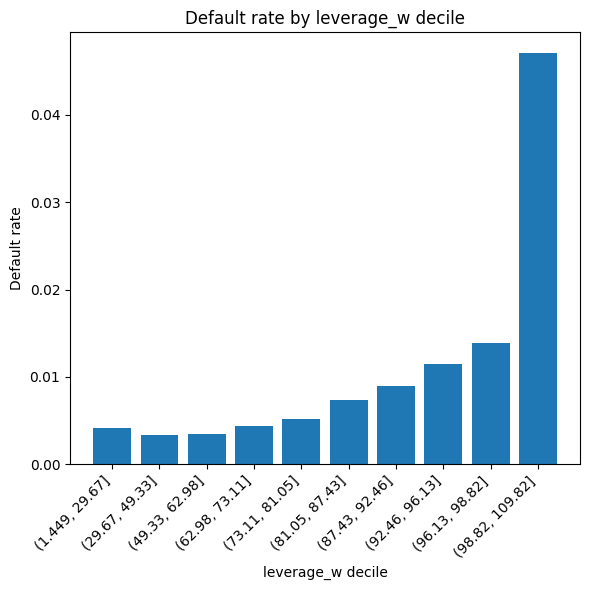

In [17]:
df["flag_missing_leverage"] = df["leverage"].isna().astype(int)

df["leverage_w"] = df["leverage"].clip(
    df["leverage"].quantile(0.01),
    df["leverage"].quantile(0.99)
)

df["leverage_w"] = df["leverage_w"].round(2)

# 1) Work only with rows where roe_calc is not missing
tmp = df[["leverage_w", "default_12m"]].dropna(subset=["leverage_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["leverage_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("leverage_w decile")
plt.title("Default rate by leverage_w decile")
plt.tight_layout()
plt.show()

In [18]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,debt_lt_approx,debt_st_approx,flag_eqty_missing,liab_tot_approx,liab_tot,flag_negative_liab,flag_negative_equity,leverage,flag_missing_leverage,leverage_w
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,473281.0,24328.0,0,1826500.0,1656958.0,False,False,85.11,0,85.11
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,548543.0,184518.0,0,2222526.0,2114671.0,False,True,101.80,0,101.80
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,550291.0,173526.0,0,2112339.0,2021013.0,False,True,102.28,0,102.28
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,399907.0,66941.0,0,2084709.0,1833688.0,False,False,97.91,0,97.91
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,124241.0,523353.0,0,1807869.0,1699062.0,False,False,96.04,0,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,1009049.0,2203680.0,0,8949222.0,7024624.0,False,False,91.84,0,91.84
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,1579094.0,1975127.0,0,6681046.0,5584862.0,False,False,89.73,0,89.73
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,1753021.0,1863399.0,0,6352586.0,5513577.0,False,False,89.71,0,89.71
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,786633.0,0.0,0,1289413.0,1289004.0,False,False,83.28,0,83.28


### ROE

In [19]:
# df = df.dropna(subset=['eqty_tot']).copy()

# Ensure numeric
df["profit"]   = pd.to_numeric(df["profit"], errors="coerce")
df["eqty_tot"] = pd.to_numeric(df["eqty_tot"], errors="coerce")


# --- 1) Base ROE calculation ---
roe = df["profit"] / df["eqty_tot"]*100


# --- 2) Rule: if eqty_tot == 0 → set ROE = NaN ---
roe = roe.mask(df["eqty_tot"] == 0, pd.NA)


# --- 3) Rule: if profit == 0 AND eqty_tot > 0 → ROE = 0 ---
roe = roe.mask((df["profit"] == 0), 0.0)

# --- 6) Save ---
df["roe_calc"] = roe.round(2)


# Summary
summary = {
    "n_equity_zero":     int((df["eqty_tot"] == 0).sum()),
    "n_profit_zero":     int((df["profit"] == 0).sum()),
}
summary

{'n_equity_zero': 15, 'n_profit_zero': 1890}

In [20]:
# Compare only where both are non-missing
mask = df["roe"].notna() & df["roe_calc"].notna()

# Boolean: same up to 2 decimals
same = np.isclose(df.loc[mask, "roe"], df.loc[mask, "roe_calc"], atol=0.01)

df["missing_roe_flag"]=df["roe"].isna().astype(int)

# --- 4) Merge original ROE with calculated one ---
df["roe_merged"] = df["roe"].fillna(df["roe_calc"])
df["roe_merged"]=df["roe_merged"].fillna(0)
# Counts
n_same = same.sum()
n_diff = (~same).sum()
n_total = mask.sum()

print(f"Compared rows: {n_total:,}")
print(f"Same (±0.01):  {n_same:,} ({n_same/n_total:.2%})")
print(f"Different:     {n_diff:,} ({n_diff/n_total:.2%})")

Compared rows: 949,664
Same (±0.01):  949,572 (99.99%)
Different:     92 (0.01%)


Created ROE_CALC Column where total equity wasn't 0 where it was 0 kept it as missing, then flagged the rows where the actual roe was missing. Then merged roe_calc with the roe column, and for the remaining missing values filled in with 0

In [21]:
df_subset = df[['roe','roe_merged','profit','eqty_tot','missing_roe_flag']]
df_subset

,roe,roe_merged,profit,eqty_tot,missing_roe_flag
0,-28.03,-28.03,-81288.0,289982.0,0
1,NaN,287.69,-107382.0,-37325.0,1
2,NaN,172.40,-77819.0,-45139.0,1
3,NaN,-639.86,-250786.0,39194.0,1
4,52.43,52.43,36733.0,70060.0,0
...,...,...,...,...,...
1023547,-43.00,-43.00,-268445.0,624227.0,0
1023548,1.01,1.01,6467.0,639000.0,0
1023549,0.62,0.62,3893.0,632533.0,0
1023550,-1.85,-1.85,-4793.0,258767.0,0


/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1264244040.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


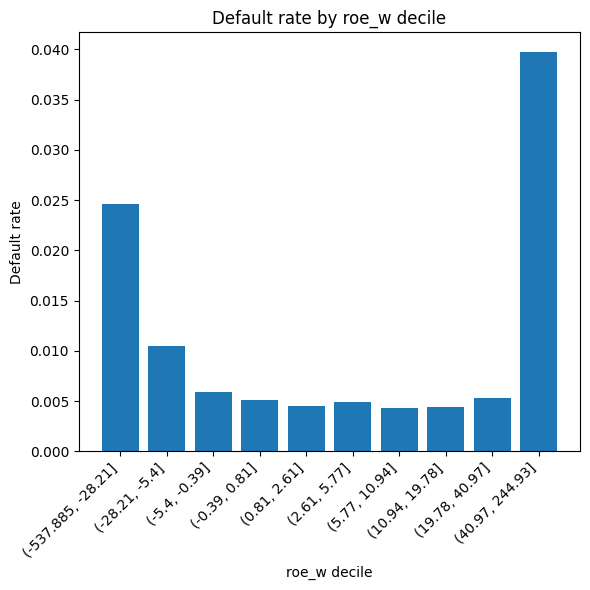

In [22]:
df["roe_w"] = df["roe_merged"].clip(
    df["roe_merged"].quantile(0.01),
    df["roe_merged"].quantile(0.99)
)

# 1) Work only with rows where roe_merged is not missing
tmp = df[["roe_w", "default_12m"]].dropna(subset=["roe_w"]).copy()

# 2) Create deciles for roe_merged (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["roe_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("roe_w decile")
plt.title("Default rate by roe_w decile")
plt.tight_layout()
plt.show()

### ROA

In [23]:
# Ensure numeric
df["prof_operations"]   = pd.to_numeric(df["prof_operations"], errors="coerce")
df["asst_tot"] = pd.to_numeric(df["asst_tot"], errors="coerce")


# --- 1) Base ROE calculation ---
roa = (df["prof_operations"]) / df["asst_tot"]*100


# --- 2) Rule: if eqty_tot == 0 → set ROE = NaN ---
roa = roa.mask(df["asst_tot"] == 0, pd.NA)


# --- 3) Rule: if profit == 0 AND eqty_tot > 0 → ROE = 0 ---
roa = roa.mask((df["prof_operations"] == 0), 0.0)

# --- 6) Save ---
df["roa_calc"] = roa.round(2)


# Summary
summary = {
    "n_asset_zero":     int((df["asst_tot"] == 0).sum()),
    "n_profit_zero":     int((df["prof_operations"] == 0).sum()),
}
summary

{'n_asset_zero': 0, 'n_profit_zero': 718}

In [24]:
# Compare only where both are non-missing
mask = df["roa"].notna() & df["roa_calc"].notna()

# Boolean: same up to 2 decimals
same = np.isclose(df.loc[mask, "roa"], df.loc[mask, "roa_calc"], atol=0.01)

df["missing_roa"]=df["roa"].isna().astype(int)

df["roa_merged"] = df["roa"].fillna(df["roa_calc"])

df["roa_merged"]=df["roa_merged"].fillna(0)

# Counts
n_same = same.sum()
n_diff = (~same).sum()
n_total = mask.sum()

print(f"Compared rows: {n_total:,}")
print(f"Same (±0.01):  {n_same:,} ({n_same/n_total:.2%})")
print(f"Different:     {n_diff:,} ({n_diff/n_total:.2%})")

Compared rows: 1,020,900
Same (±0.01):  1,020,865 (100.00%)
Different:     35 (0.00%)


In [25]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,leverage,flag_missing_leverage,leverage_w,roe_calc,missing_roe_flag,roe_merged,roe_w,roa_calc,missing_roa,roa_merged
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,85.11,0,85.11,-28.03,0,-28.03,-28.0300,-3.81,0,-3.81
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,101.80,0,101.80,287.69,1,287.69,244.9296,-2.76,0,-2.76
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,102.28,0,102.28,172.40,1,172.40,172.4000,-2.17,0,-2.17
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,97.91,0,97.91,-639.86,1,-639.86,-537.8840,-12.99,0,-12.99
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,96.04,0,96.04,52.43,0,52.43,52.4300,6.20,0,6.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,91.84,0,91.84,-43.00,0,-43.00,-43.0000,2.16,0,2.16
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,89.73,0,89.73,1.01,0,1.01,1.0100,12.97,0,12.97
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,89.71,0,89.71,0.62,0,0.62,0.6200,6.15,0,6.15
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,83.28,0,83.28,-1.85,0,-1.85,-1.8500,-0.31,0,-0.31


/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/881704961.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


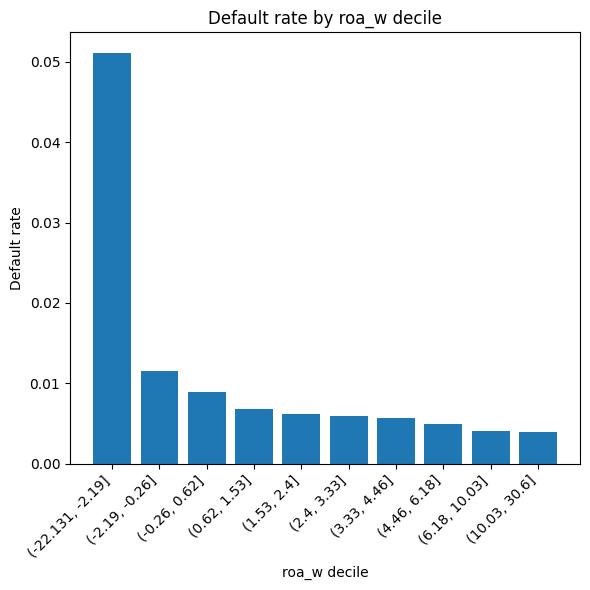

In [26]:
df["roa_w"] = df["roa_merged"].clip(
    df["roa_merged"].quantile(0.01),
    df["roa_merged"].quantile(0.99)
)

# 1) Work only with rows where roe_calc is not missing
tmp = df[["roa_w", "default_12m"]].dropna(subset=["roa_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["roa_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("roa_w decile")
plt.title("Default rate by roa_w decile")
plt.tight_layout()
plt.show()

We calculate ROA on using prof_operations/asst_tot, this formula is NA only when prof_operations is missing or total asset is missing. Using the decile plot we can see as roa increases the probability of default decreases.

### Ebitda

Missing Values are there 79 from default and 2 from non default 

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/986174310.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


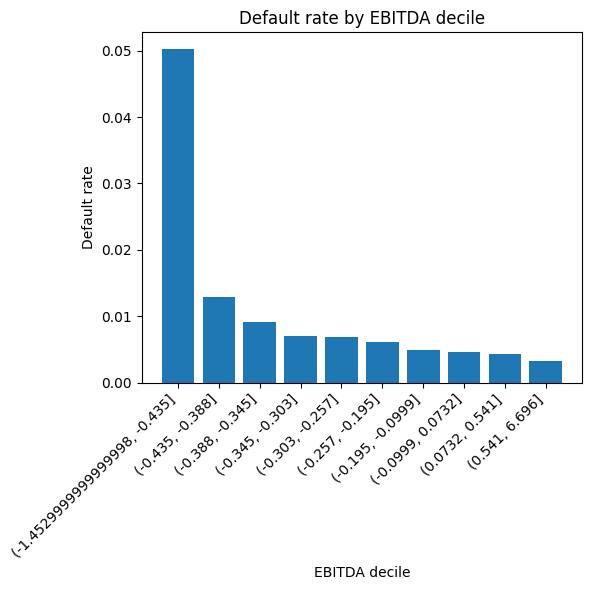

In [27]:
df["flag_missing_ebitda"]=df["ebitda"].isna().astype(int)

df["ebitda"]=df["ebitda"].fillna(0)

df["ebitda_w"] = df["ebitda"].clip(
    df["ebitda"].quantile(0.01),
    df["ebitda"].quantile(0.99)
)

# Compute mean and std on TRAIN ONLY
mu  = df["ebitda_w"].mean()
std = df["ebitda_w"].std()

# Apply standardization to train
df["ebitda_std"] = (df["ebitda_w"] - mu) / std


# 1) Work only with rows where EBITDA is not missing
tmp = df[["ebitda_std", "default_12m"]].dropna(subset=["ebitda_std"]).copy()

# 2) Create deciles for EBITDA (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["ebitda_std"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("EBITDA decile")
plt.title("Default rate by EBITDA decile")
plt.tight_layout()
plt.show()

### Prof_Operations

Missing values are present 21 from non default only

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/115741301.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


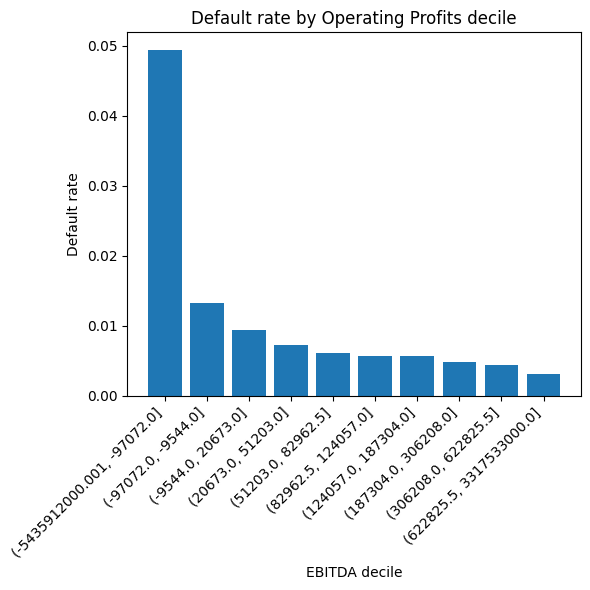

In [28]:
# 1) Work only with rows where EBITDA is not missing
tmp = df[["prof_operations", "default_12m"]].dropna(subset=["prof_operations"]).copy()

# 2) Create deciles for EBITDA (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["prof_operations"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("EBITDA decile")
plt.title("Default rate by Operating Profits decile")
plt.tight_layout()
plt.show()

### Margin_Calc

In [29]:
# 1️⃣ Recalculate margin_fin from components
df["margin_calc"] = (
    df["eqty_tot"]
    - df[["asst_intang_fixed", "asst_tang_fixed", "asst_fixed_fin"]].sum(axis=1)
)

# 2️⃣ Create missing flag
df["missing_margin_flag"] = df["margin_fin"].isna().astype(int)

# 3️⃣ Create a filled version (use reported if available, else calculated)
df["margin_fin_filled"] = np.where(
    df["margin_fin"].notna(), df["margin_fin"], df["margin_calc"]
)

# 4️⃣ Quick check
print("\n=== margin_fin Missingness Summary ===")
n_total = len(df)
n_missing = df["missing_margin_flag"].sum()
print(f"Total rows:       {n_total:,}")
print(f"Missing margin:   {n_missing:,} ({n_missing/n_total*100:.2f}%)")
print(f"Filled values:    {n_total - n_missing:,} ({(n_total - n_missing)/n_total*100:.2f}%)")

# 5️⃣ Sanity check of valid rows comparison (optional)
mask = df["margin_fin"].notna() & df["margin_calc"].notna()
same = (np.abs(df.loc[mask, "margin_calc"] - df.loc[mask, "margin_fin"]) < 0.01).sum()
print(f"\nOf {mask.sum():,} valid rows, {same:,} ({same/mask.sum()*100:.2f}%) match within ±0.01")

# (Optional) look at flag effect
print("\nFlag correlation with default rate:")
print(df.groupby("missing_margin_flag")["default_12m"].mean())


=== margin_fin Missingness Summary ===
Total rows:       1,020,927
Missing margin:   39,329 (3.85%)
Filled values:    981,598 (96.15%)

Of 981,598 valid rows, 979,934 (99.83%) match within ±0.01

Flag correlation with default rate:
missing_margin_flag
0    0.007494
1    0.096621
Name: default_12m, dtype: float64


/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/2225109990.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


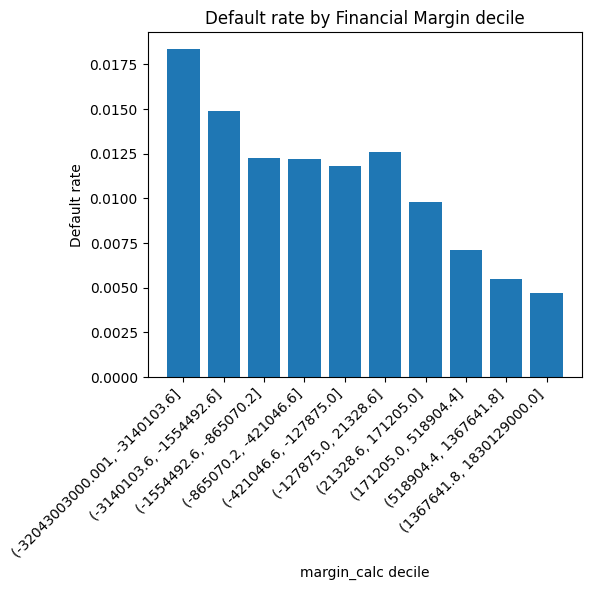

In [30]:
# 1) Work only with rows where margin_calc is not missing
tmp = df[["margin_calc", "default_12m"]].dropna(subset=["margin_calc"]).copy()

# 2) Create deciles for margin_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["margin_calc"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "margin_calc decile")
plt.title("Default rate by Financial Margin decile")
plt.tight_layout()
plt.show()

### DSO

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1806235948.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


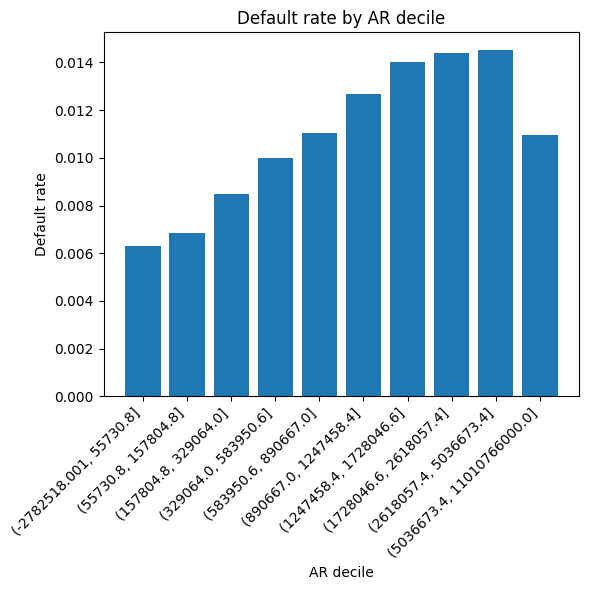

In [31]:
# 1) Work only with rows where AR is not missing
tmp = df[["AR", "default_12m"]].dropna(subset=["AR"]).copy()

# 2) Create deciles for AR (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["AR"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "AR decile")
plt.title("Default rate by AR decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1807312144.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


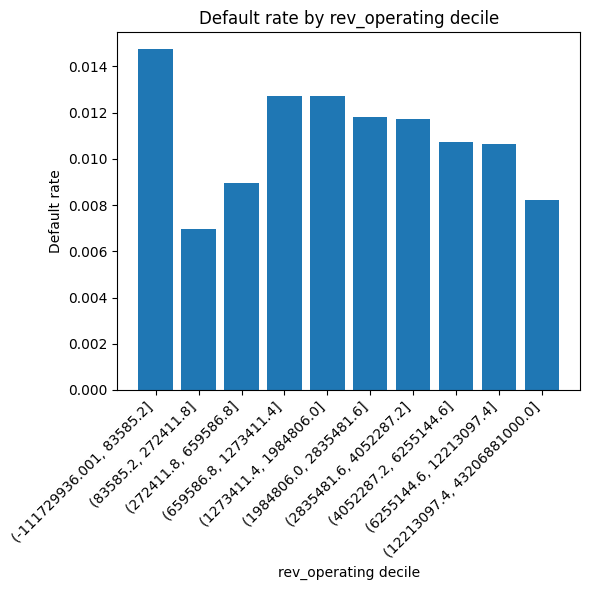

In [32]:
# 1) Work only with rows where rev_operating is not missing
tmp = df[["rev_operating", "default_12m"]].dropna(subset=["rev_operating"]).copy()

# 2) Create deciles for rev_operating (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["rev_operating"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "rev_operating decile")
plt.title("Default rate by rev_operating decile")
plt.tight_layout()
plt.show()

In [33]:
df["DSO"] = np.where(
    df["rev_operating"].notna() & (df["rev_operating"] != 0) & df["AR"].notna(),
    (df["AR"] / df["rev_operating"]) * 365,
    np.nan
)

# df["DSO_std"]=((df["DSO"]-df["DSO"].mean())/df["DSO"].std())
df["DSO_std"]=df["DSO"]

upper_cap = df["DSO"].abs().quantile(0.995)
df["DSO"] = df["DSO"].clip(-upper_cap, upper_cap)

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/1425876912.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


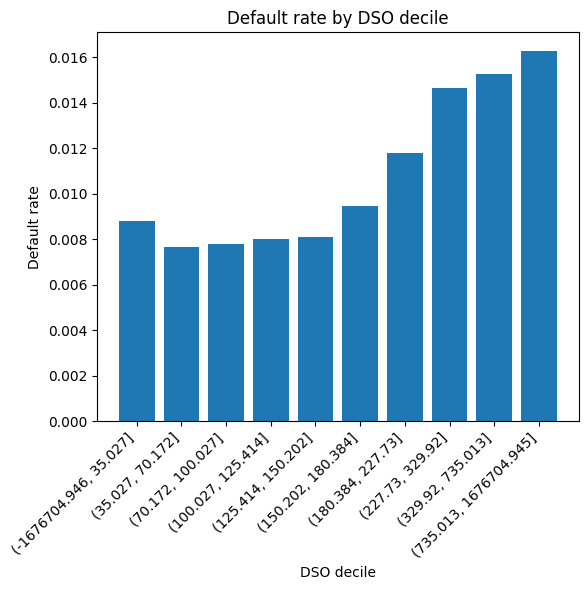

In [34]:
# 1) Work only with rows where DSO is not missing
tmp = df[["DSO", "default_12m"]].dropna(subset=["DSO"]).copy()

# 2) Create deciles for DSO (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["DSO"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "DSO decile")
plt.title("Default rate by DSO decile")
plt.tight_layout()
plt.show()

### Cash FLow Statment

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/332452793.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


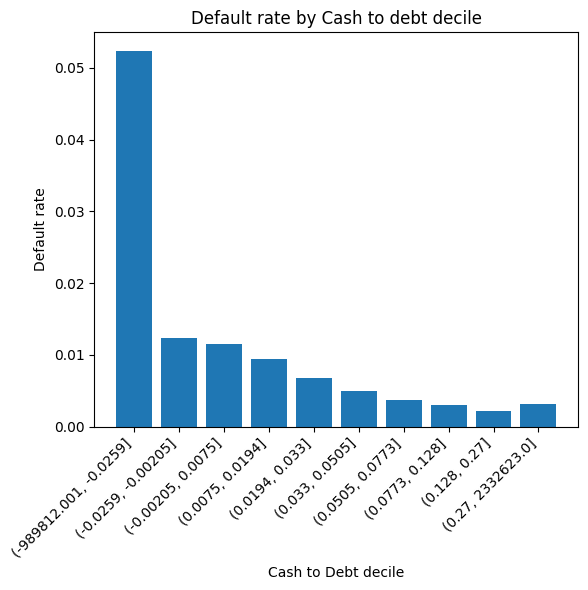

In [35]:

# Total interest-bearing debt
df["debt_total"] = (
    df["debt_lt"].fillna(0) +
    df["debt_st"].fillna(0)
)

denom = df["debt_total"].copy()
denom = denom.mask(df["debt_total"] == 0, 1)  # avoid div by 0

df["cf_to_debt"] = df["cf_operations"] / denom

df["cf_to_debt"]=df["cf_to_debt"].fillna(0)

tmp = df[["cf_to_debt", "default_12m"]].dropna(subset=["cf_to_debt"]).copy()

#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["cf_to_debt"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "Cash to Debt decile")
plt.title("Default rate by Cash to debt decile")
plt.tight_layout()
plt.show()


In [36]:
df_subset = df[['cf_to_debt',"cf_operations","debt_lt","debt_st",'default_12m']]

In [37]:
df_subset

,cf_to_debt,cf_operations,debt_lt,debt_st,default_12m
0,-0.000538,-849.0,1340801.0,237238.0,0.0
1,-0.001896,-3881.0,1521607.0,525040.0,0.0
2,0.016713,32618.0,1125755.0,825923.0,0.0
3,-0.096876,-168907.0,1377427.0,366108.0,0.0
4,0.048982,80039.0,832305.0,801760.0,0.0
...,...,...,...,...,...
1023547,0.082212,550755.0,1559049.0,5140176.0,0.0
1023548,0.170187,945705.0,2129094.0,3427755.0,0.0
1023549,0.213544,1166064.0,2303021.0,3157512.0,0.0
1023550,-0.003718,-4793.0,1288595.0,409.0,0.0


#

In [38]:
df["Financial_Leverage"]=df["roa_merged"]-df["roe_merged"]
# lower_cap_fl = df["Financial_Leverage"].quantile(0.01)
# upper_cap_fl = df["Financial_Leverage"].quantile(0.99)
# df["Financial_Leverage_w"] = df["Financial_Leverage"].clip(lower=lower_cap_fl, upper=upper_cap_fl)

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/2951490907.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


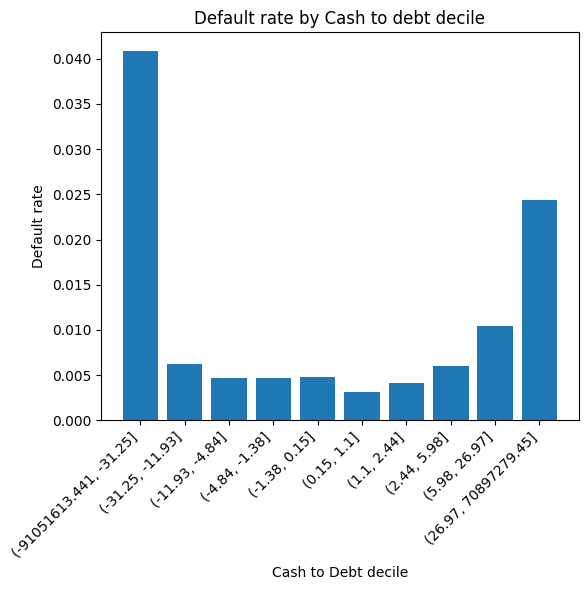

In [39]:
tmp = df[["Financial_Leverage", "default_12m"]].dropna(subset=["Financial_Leverage"]).copy()

#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["Financial_Leverage"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "Cash to Debt decile")
plt.title("Default rate by Cash to debt decile")
plt.tight_layout()
plt.show()


/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/4131069988.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


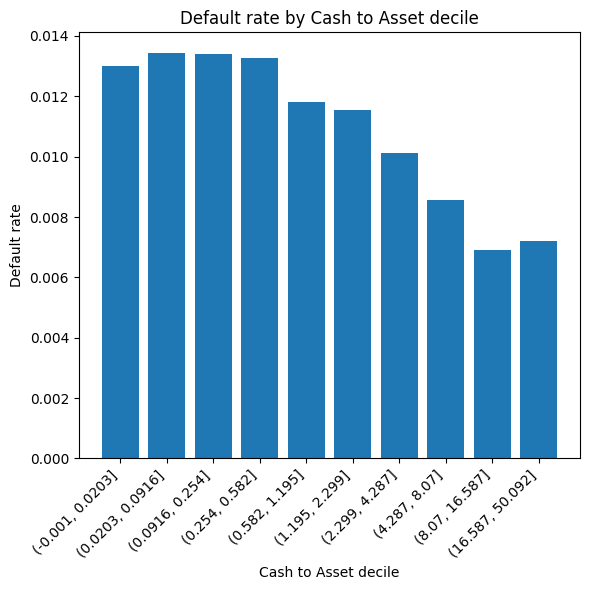

In [40]:
cash_to_assets = df["cash_and_equiv"].fillna(0) / df["asst_tot"] * 100
cash_to_assets = cash_to_assets.mask(df["asst_tot"] == 0, pd.NA).fillna(0)
cta_p1 = np.percentile(cash_to_assets.dropna(), 1)
cta_p99 = np.percentile(cash_to_assets.dropna(), 99)
df["cash_to_assets_w"] = cash_to_assets.clip(lower=cta_p1, upper=cta_p99)

tmp = df[["cash_to_assets_w", "default_12m"]].dropna(subset=["cash_to_assets_w"]).copy()

#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["cash_to_assets_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "Cash to Asset decile")
plt.title("Default rate by Cash to Asset decile")
plt.tight_layout()
plt.show()


/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_818/152098187.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


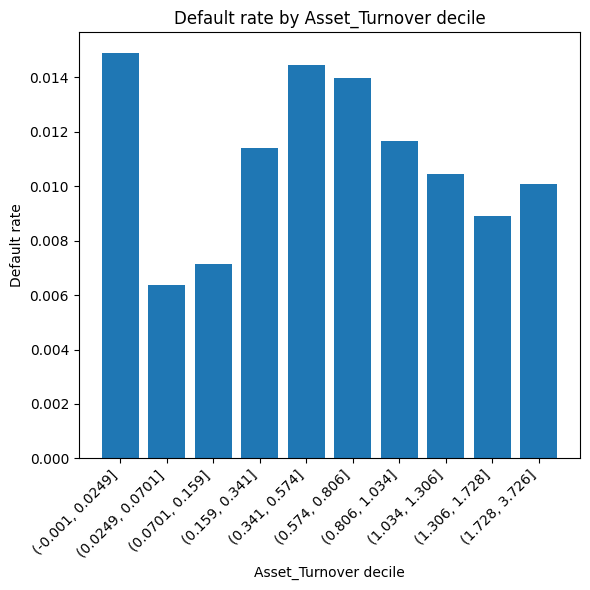

In [41]:
# FEATURE 5: ASSET_TURNOVER_W (Efficiency) - z=4.34, p<0.001
df["rev_operating_missing"]=df["rev_operating"].isna().astype(int)
asset_turnover = df["rev_operating"].fillna(0) / df["asst_tot"]
asset_turnover = asset_turnover.mask(df["asst_tot"] == 0, pd.NA).fillna(0)
at_p1 = np.percentile(asset_turnover, 1)
at_p99 = np.percentile(asset_turnover, 99)
df["asset_turnover_w"] = asset_turnover.clip(lower=at_p1, upper=at_p99)

tmp = df[["asset_turnover_w", "default_12m"]].dropna(subset=["asset_turnover_w"]).copy()

#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["asset_turnover_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel( "Asset_Turnover decile")
plt.title("Default rate by Asset_Turnover decile")
plt.tight_layout()
plt.show()

# Validation

In [42]:
# df.to_csv("data/Default_final.csv", index=False)

In [43]:
train_df = df[df["avail_date"] < "2011-05-01"].copy()
test_df  = df[df["avail_date"] >= "2011-05-01"].copy()

In [44]:
train_df["roa_w"] = train_df["roa_merged"].clip(
    df["roa_merged"].quantile(0.01),
    df["roa_merged"].quantile(0.99)
)

# Compute mean and std on TRAIN ONLY
mu  = train_df["roa_w"].mean()
std = train_df["roa_w"].std()

# Apply standardization to train
train_df["roa_std"] = (train_df["roa_w"] - mu) / std

train_df["roe_w"] = train_df["roe_merged"].clip(
    df["roe_merged"].quantile(0.01),
    df["roe_merged"].quantile(0.99)
)


train_df["roe_sq"] = train_df["roe_w"] ** 2

# Compute mean and std on TRAIN ONLY
mu  = train_df["roe_w"].mean()
std = train_df["roe_w"].std()

# Apply standardization to train
train_df["roe_std"] = (train_df["roe_w"] - mu) / std

# Compute mean and std on TRAIN ONLY
mu  = train_df["roe_sq"].mean()
std = train_df["roe_sq"].std()

# Apply standardization to train
train_df["roe_sq_std"] = (train_df["roe_sq"] - mu) / std



train_df["ebitda"]=train_df["ebitda"].clip(
    df["ebitda"].quantile(0.01),
    df["ebitda"].quantile(0.99)
)

# Compute mean and std on TRAIN ONLY
mu  = train_df["ebitda"].mean()
std = train_df["ebitda"].std()

# Apply standardization to train
train_df["ebitda_std"] = (train_df["ebitda"] - mu) / std

train_df["AR"]=train_df["AR"].clip(
    df["AR"].quantile(0.01),
    df["AR"].quantile(0.99)
)

# Compute mean and std on TRAIN ONLY
mu  = train_df["AR"].mean()
std = train_df["AR"].std()

# Apply standardization to train
train_df["AR_std"] = (train_df["AR"] - mu) / std

train_df["leverage_w"] = train_df["leverage"].clip(
    train_df["leverage"].quantile(0.01),
    train_df["leverage"].quantile(0.99)
)

train_df["margin_fin_filled"]=train_df["margin_fin_filled"].clip(
    df["margin_fin_filled"].quantile(0.01),
    df["margin_fin_filled"].quantile(0.99)
)

# Compute mean and std on TRAIN ONLY
mu  = train_df["margin_fin_filled"].mean()
std = train_df["margin_fin_filled"].std()

# Apply standardization to train
train_df["margin_fin_filled_std"] = (train_df["margin_fin_filled"] - mu) / std


# 1. Winsorize (1st–99th percentile)
lower = train_df["cf_to_debt"].quantile(0.01)
upper = train_df["cf_to_debt"].quantile(0.99)

train_df["cf_to_debt_w"] = train_df["cf_to_debt"].clip(lower, upper)

# 2. Standardize (Z-score)
mean = train_df["cf_to_debt_w"].mean()
std  = train_df["cf_to_debt_w"].std()

train_df["cf_to_debt_std"] = (train_df["cf_to_debt_w"] - mean) / std


lower_cap_fl = train_df["Financial_Leverage"].quantile(0.01)
upper_cap_fl = train_df["Financial_Leverage"].quantile(0.99)
train_df["Financial_Leverage_w"] = train_df["Financial_Leverage"].clip(lower=lower_cap_fl, upper=upper_cap_fl)

In [45]:
train_df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,asset_turnover_w,roa_std,roe_sq,roe_std,roe_sq_std,AR_std,margin_fin_filled_std,cf_to_debt_w,cf_to_debt_std,Financial_Leverage_w
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,0.465685,-0.876092,59990.508956,3.047434,1.640903,-0.397248,-0.198806,-0.001896,-0.338743,-257.56
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,0.323243,-0.791246,29721.760000,2.148671,0.712131,-0.397124,-0.176247,0.016713,-0.283171,-174.57
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,1.153767,0.412408,2748.904900,0.662042,-0.115509,-0.383429,-0.120617,0.048982,-0.186806,-46.23
5,23,520288,2010-12-31,28.0,SRL,14.0,NaN,2010,130973.0,1136731.0,...,0.297545,-1.065915,507.150400,-0.266715,-0.184296,-0.419184,-0.043363,-0.001443,-0.337388,18.44
6,35,1400357,2010-12-31,35.0,SRL,49.0,NaN,2010,10733.0,1017560.0,...,0.808083,0.131987,40.068900,0.090785,-0.198628,-0.433242,0.114152,0.093555,-0.053696,-2.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023544,4885788,92001230520,2010-12-31,52.0,SPA,93.0,NaN,2010,1772410.0,278312.0,...,2.373171,-0.634498,1490.732100,-0.466097,-0.154115,0.644075,-0.159209,0.081896,-0.088515,37.53
1023546,4885790,92001230520,2009-12-31,52.0,SPA,93.0,NaN,2009,2116710.0,301147.0,...,3.726215,0.387961,0.302500,0.019161,-0.199848,-0.033024,-0.312378,0.210212,0.294677,5.48
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,2.801899,1.385974,1.020100,0.024862,-0.199826,0.127872,-0.396653,0.170187,0.175150,11.96
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,2.257203,0.405218,0.384400,0.020029,-0.199846,0.146116,-0.348551,0.213544,0.304627,5.53


In [46]:
test_df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,missing_margin_flag,margin_fin_filled,DSO,DSO_std,debt_total,cf_to_debt,Financial_Leverage,cash_to_assets_w,rev_operating_missing,asset_turnover_w
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,0,-917029.0,191.978057,191.978057,1578039.0,-0.000538,24.22,0.106988,0,0.276373
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,0,-1094962.0,328.546796,328.546796,1743535.0,-0.096876,626.87,0.349622,0,0.170748
9,39,1400357,2011-12-31,35.0,SRL,49.0,NaN,2011,6966.0,1065000.0,...,0,-294830.0,64.071562,64.071562,761871.0,0.157229,-2.23,16.520810,0,0.788276
12,50,1650282,2012-12-31,27.0,SRL,25.0,NaN,2012,14380.0,1151565.0,...,0,737799.0,99.334002,99.334002,8378109.0,0.055605,-11.68,29.739056,0,1.521866
15,54,1650282,2011-12-31,27.0,SRL,25.0,NaN,2011,14394.0,1228444.0,...,0,673525.0,243.348215,243.348215,9281436.0,0.047629,-4.14,5.555077,0,1.183066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023540,4885784,90007390041,2011-12-31,1.0,SRL,68.0,NaN,2011,0.0,0.0,...,0,-350366.0,8674.312093,8674.312093,2144562.0,-0.005334,-0.03,0.025540,0,0.009728
1023542,4885786,90007390041,2012-12-31,1.0,SRL,68.0,NaN,2012,0.0,0.0,...,0,-814619.0,7314.662939,7314.662939,2509614.0,-0.065449,0.91,0.373424,0,0.010522
1023545,4885789,92001230520,2012-12-31,52.0,SPA,93.0,NaN,2012,899424.0,201592.0,...,0,-303369.0,169.157278,169.157278,6911893.0,0.147750,-86.11,0.027052,0,1.699803
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,0,-1286111.0,95.310876,95.310876,6699225.0,0.082212,45.16,0.008132,0,2.675718


In [47]:
variable_pd_analysis(
    train_df,
    var_names=['roe_w','missing_roe_flag','roa_w','missing_margin_flag','ebitda_std','leverage_w',"cf_to_debt_std","Financial_Leverage_w"],
    target='default_12m',
    date_col='avail_date',
    combined=True,
    cluster_by='id',
    drop_na='pairwise',
    combined_only=True
)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:               651390
Model:                          Logit   Df Residuals:                   651381
Method:                           MLE   Df Model:                            8
Date:                Wed, 19 Nov 2025   Pseudo R-squ.:                  0.1682
Time:                        18:30:22   Log-Likelihood:                -37562.
converged:                       True   LL-Null:                       -45157.
Covariance Type:              cluster   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.9773      0.066    -90.032      0.000  

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x119f33eb0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x119f32e30>,
 'corr_combined':                          roe_w  missing_roe_flag     roa_w  \
 roe_w                 1.000000         -0.254125  0.248950   
 missing_roe_flag     -0.254125          1.000000 -0.305445   
 roa_w                 0.248950         -0.305445  1.000000   
 missing_margin_flag   0.352242          0.699641 -0.223410   
 ebitda_std            0.099040         -0.132405  0.412650   
 leverage_w           -0.063920          0.283821 -0.133100   
 cf_to_debt_std        0.118701         -0.142382  0.362023   
 Financial_Leverage_w -0.993168          0.212742 -0.150415   
 
                       missing_margin_flag  ebitda_std  leverage_w  \
 roe_w                            0.352242    0.099040   -0.063920   
 missing_roe_flag                